# JEPA Phase 1 + Phase 2 Continuous Training

Run this notebook with Jupyter/VS Code `Run All`, not with `python JEPA.ipynb`. The file is notebook JSON, so Python cannot execute it directly.

## Config

In [49]:
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import models as tv_models

VIDEO_PATH = "data/QAvideo1.mp4"  # set to a video path, e.g. "data/video3.mp4"; None uses IMAGE_PATH
IMAGE_PATH = "data/dog.png"  # set to an RGB image path, e.g. "data/dog.png"; None uses VIDEO_PATH
CHECKPOINT_PATH = "frequency_jepa_sr.pth"
PHASE1_CHECKPOINT_PATH = "phase1_jepa.pth"
PHASE1_READY_FOR_PHASE2_PATH = "jepa_ready_for_phase2.pth"
INFERENCE_OUTPUT_PATH = "final_reconstruction.jpg"

# Used only when frequency_jepa_sr.pth does not exist.
PHASE1_CHECKPOINT_CANDIDATES = [
    PHASE1_READY_FOR_PHASE2_PATH,
    PHASE1_CHECKPOINT_PATH,
]

# Every Run All adds this many more phase-1 epochs before phase 2.
PHASE1_ADDITIONAL_EPOCHS = 1
PHASE1_LEARNING_RATE = 1e-4
PHASE1_WEIGHT_DECAY = 1e-4
PHASE1_EMA_DECAY = 0.996
PHASE1_MAX_STEPS_PER_EPOCH = None  # set to an int for quick tests, e.g. 20

# Every Run All adds this many more phase-2 epochs.
ADDITIONAL_EPOCHS = 5
BATCH_SIZE = 16
MAX_STEPS_PER_EPOCH = None  # set to an int for quick tests, e.g. 20
SAVE_EVERY_STEPS = 100
LEARNING_RATE = 1e-3
TARGET_HW = (256, 256)
RADIUS_RATIO = 0.25
LATENT_DIM = 256
PREDICTOR_HIDDEN_DIM = 512
USE_PRETRAINED_BACKBONE = False
ARCHITECTURE_VERSION = "mobilenet_2ch_phase2_v1"

# Recommendations:
# - For better reconstruction, try PHASE1_ADDITIONAL_EPOCHS = 5 and ADDITIONAL_EPOCHS = 10
# - Increase LATENT_DIM to 512 or 1024 if your GPU memory allows it
# - Set USE_PRETRAINED_BACKBONE = True to fine-tune a pre-trained MobileNet encoder

if "train_phase_1" in globals():
    del train_phase_1
if "train_phase_2" in globals():
    del train_phase_2

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Model Architect

In [35]:
class JEPAEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, pretrained=False):
        super().__init__()
        weights = None
        if pretrained:
            try:
                weights = tv_models.MobileNet_V3_Small_Weights.DEFAULT
            except Exception:
                weights = None
        self.backbone = tv_models.mobilenet_v3_small(weights=weights)

        orig_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=2,
            out_channels=orig_conv.out_channels,
            kernel_size=orig_conv.kernel_size,
            stride=orig_conv.stride,
            padding=orig_conv.padding,
            bias=False,
        )

        in_feat = self.backbone.classifier[3].in_features
        self.backbone.classifier[3] = nn.Linear(in_feat, latent_dim)

    def forward(self, x):
        return self.backbone(x)


class JEPAPredictor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=PREDICTOR_HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, s_x):
        return self.net(s_x)


class JEPADecoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, target_hw=(256, 256)):
        super().__init__()
        combined_dim = latent_dim * 2
        self.init_h = target_hw[0] // 16
        self.init_w = target_hw[1] // 16

        self.fc = nn.Linear(combined_dim, 256 * self.init_h * self.init_w)
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.ConvTranspose2d(32, 2, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, s_x, s_y_pred):
        z = torch.cat([s_x, s_y_pred], dim=1)
        z = self.fc(z)
        z = z.view(-1, 256, self.init_h, self.init_w)
        return self.upsample(z)

## Frequency Data

In [36]:
class Extraction:
    def __init__(self, target_hw=(256, 256), radius_ratio=0.25, device="cpu"):
        self.target_hw = target_hw
        self.radius_ratio = radius_ratio
        self.device = torch.device(device)
        self._mask_cache = {}

    def _create_circular_mask(self, height, width):
        cache_key = (height, width, self.device.type, self.device.index, self.radius_ratio)
        if cache_key in self._mask_cache:
            return self._mask_cache[cache_key]

        max_radius = min(height, width) / 2.0
        radius_sq = (max_radius * self.radius_ratio) ** 2
        y, x = torch.meshgrid(
            torch.arange(height, device=self.device),
            torch.arange(width, device=self.device),
            indexing="ij",
        )

        center_y, center_x = height // 2, width // 2
        dist_sq = (y - center_y).square() + (x - center_x).square()
        mask = (dist_sq <= radius_sq).view(1, 1, height, width)
        self._mask_cache[cache_key] = mask
        return mask

    def stream_video_batches(self, video_path, batch_size=32):
        cap = cv2.VideoCapture(str(video_path))
        height, width = self.target_hw
        frame_buffer = np.empty((batch_size, height, width), dtype=np.uint8)

        try:
            while True:
                filled = 0
                while filled < batch_size:
                    ret, frame = cap.read()
                    if not ret:
                        break

                    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                    frame_buffer[filled] = cv2.resize(gray_frame, (width, height), interpolation=cv2.INTER_AREA)
                    filled += 1

                if filled == 0:
                    break

                cpu_tensor = torch.from_numpy(frame_buffer[:filled])
                if self.device.type == "cuda":
                    cpu_tensor = cpu_tensor.pin_memory()

                with torch.no_grad():
                    spatial_tensor = cpu_tensor.to(
                        device=self.device,
                        dtype=torch.float32,
                        non_blocking=self.device.type == "cuda",
                    ).unsqueeze(1).mul_(1.0 / 255.0)

                    fft_complex = torch.fft.fftshift(torch.fft.fft2(spatial_tensor))
                    low_pass_mask = self._create_circular_mask(height, width)
                    low_freq_complex = fft_complex * low_pass_mask
                    high_freq_complex = fft_complex - low_freq_complex

                    low_frequency = torch.cat([low_freq_complex.real, low_freq_complex.imag], dim=1)
                    high_frequency = torch.cat([high_freq_complex.real, high_freq_complex.imag], dim=1)

                yield low_frequency, high_frequency
        finally:
            cap.release()


## Checkpoint Helpers

In [37]:
def torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)


def build_phase2_models():
    context_encoder = JEPAEncoder(latent_dim=LATENT_DIM, pretrained=USE_PRETRAINED_BACKBONE).to(device)
    target_encoder = JEPAEncoder(latent_dim=LATENT_DIM).to(device)
    predictor = JEPAPredictor(latent_dim=LATENT_DIM, hidden_dim=PREDICTOR_HIDDEN_DIM).to(device)
    decoder = JEPADecoder(latent_dim=LATENT_DIM, target_hw=TARGET_HW).to(device)
    optimizer_phase_2 = optim.Adam(decoder.parameters(), lr=LEARNING_RATE)
    return context_encoder, target_encoder, predictor, decoder, optimizer_phase_2


def load_phase1_if_available(context_encoder, target_encoder, predictor):
    for candidate in PHASE1_CHECKPOINT_CANDIDATES:
        path = Path(candidate)
        if not path.exists():
            continue

        checkpoint = torch_load(path, device)
        context_encoder.load_state_dict(checkpoint["context_encoder"])
        target_encoder.load_state_dict(checkpoint.get("target_encoder", checkpoint["context_encoder"]))
        predictor.load_state_dict(checkpoint["predictor"])
        print(f"No {CHECKPOINT_PATH}. Loaded phase-1 weights from {path}.")
        return True

    target_encoder.load_state_dict(context_encoder.state_dict())
    print(f"No {CHECKPOINT_PATH} and no phase-1 checkpoint found. Beginning phase 2 from fresh weights.")
    return False


def load_or_begin_phase2():
    context_encoder, target_encoder, predictor, decoder, optimizer_phase_2 = build_phase2_models()
    checkpoint_path = Path(CHECKPOINT_PATH)

    if checkpoint_path.exists():
        checkpoint = torch_load(checkpoint_path, device)
        saved_arch = checkpoint.get("architecture_version")
        if saved_arch is not None and saved_arch != ARCHITECTURE_VERSION:
            raise RuntimeError(
                f"{CHECKPOINT_PATH} was saved for {saved_arch}, but this notebook uses {ARCHITECTURE_VERSION}."
            )

        context_encoder.load_state_dict(checkpoint["context_encoder"])
        target_encoder.load_state_dict(checkpoint.get("target_encoder", checkpoint["context_encoder"]))
        predictor.load_state_dict(checkpoint["predictor"])
        decoder.load_state_dict(checkpoint["decoder"])

        optimizer_state = checkpoint.get("optimizer_phase_2")
        if optimizer_state is not None:
            optimizer_phase_2.load_state_dict(optimizer_state)

        start_epoch = int(checkpoint.get("epoch", -1)) + 1
        global_step = int(checkpoint.get("global_step", 0))
        loss_history = checkpoint.get("loss_history", {})
        print(f"Found {CHECKPOINT_PATH}. Continue phase-2 training from epoch {start_epoch + 1}.")
    else:
        load_phase1_if_available(context_encoder, target_encoder, predictor)
        start_epoch = 0
        global_step = 0
        loss_history = {}

    return context_encoder, target_encoder, predictor, decoder, optimizer_phase_2, start_epoch, global_step, loss_history


def save_phase2_checkpoint(
    epoch,
    global_step,
    context_encoder,
    target_encoder,
    predictor,
    decoder,
    optimizer_phase_2,
    loss_history=None,
):
    checkpoint_path = Path(CHECKPOINT_PATH)
    tmp_path = checkpoint_path.with_name(f"{checkpoint_path.name}.tmp")

    torch.save(
        {
            "phase": 2,
            "epoch": epoch,
            "global_step": global_step,
            "architecture_version": ARCHITECTURE_VERSION,
            "context_encoder": context_encoder.state_dict(),
            "target_encoder": target_encoder.state_dict(),
            "predictor": predictor.state_dict(),
            "decoder": decoder.state_dict(),
            "optimizer_phase_2": optimizer_phase_2.state_dict(),
            "loss_history": loss_history or {},
            "config": {
                "video_path": VIDEO_PATH,
                "additional_epochs": ADDITIONAL_EPOCHS,
                "batch_size": BATCH_SIZE,
                "max_steps_per_epoch": MAX_STEPS_PER_EPOCH,
                "save_every_steps": SAVE_EVERY_STEPS,
                "learning_rate": LEARNING_RATE,
                "target_hw": TARGET_HW,
                "radius_ratio": RADIUS_RATIO,
            },
        },
        tmp_path,
    )
    tmp_path.replace(checkpoint_path)
    print(f"Saved checkpoint: {checkpoint_path}")


## Train Phase 1

In [38]:
def build_phase1_models():
    context_encoder = JEPAEncoder(latent_dim=LATENT_DIM, pretrained=USE_PRETRAINED_BACKBONE).to(device)
    target_encoder = JEPAEncoder(latent_dim=LATENT_DIM).to(device)
    target_encoder.load_state_dict(context_encoder.state_dict())
    predictor = JEPAPredictor(latent_dim=LATENT_DIM, hidden_dim=PREDICTOR_HIDDEN_DIM).to(device)

    for param in target_encoder.parameters():
        param.requires_grad = False

    optimizer_phase_1 = optim.AdamW(
        list(context_encoder.parameters()) + list(predictor.parameters()),
        lr=PHASE1_LEARNING_RATE,
        weight_decay=PHASE1_WEIGHT_DECAY,
    )
    return context_encoder, target_encoder, predictor, optimizer_phase_1


def load_or_begin_phase1():
    context_encoder, target_encoder, predictor, optimizer_phase_1 = build_phase1_models()
    checkpoint_path = Path(PHASE1_CHECKPOINT_PATH)

    if checkpoint_path.exists():
        checkpoint = torch_load(checkpoint_path, device)
        saved_arch = checkpoint.get("architecture_version")
        if saved_arch is not None and saved_arch != ARCHITECTURE_VERSION:
            raise RuntimeError(
                f"{PHASE1_CHECKPOINT_PATH} was saved for {saved_arch}, but this notebook uses {ARCHITECTURE_VERSION}."
            )

        context_encoder.load_state_dict(checkpoint["context_encoder"])
        target_encoder.load_state_dict(checkpoint.get("target_encoder", checkpoint["context_encoder"]))
        predictor.load_state_dict(checkpoint["predictor"])

        optimizer_state = checkpoint.get("optimizer_phase_1")
        if optimizer_state is not None:
            optimizer_phase_1.load_state_dict(optimizer_state)

        start_epoch = int(checkpoint.get("epoch", -1)) + 1
        global_step = int(checkpoint.get("global_step", 0))
        loss_history = checkpoint.get("loss_history", {})
        print(f"Found {PHASE1_CHECKPOINT_PATH}. Continue phase-1 training from epoch {start_epoch + 1}.")
    else:
        start_epoch = 0
        global_step = 0
        loss_history = {}
        print(f"No {PHASE1_CHECKPOINT_PATH}. Beginning phase 1 from fresh weights.")

    for param in target_encoder.parameters():
        param.requires_grad = False

    return context_encoder, target_encoder, predictor, optimizer_phase_1, start_epoch, global_step, loss_history


@torch.no_grad()
def update_target_encoder_ema(context_encoder, target_encoder, decay=PHASE1_EMA_DECAY):
    for context_param, target_param in zip(context_encoder.parameters(), target_encoder.parameters()):
        target_param.data.mul_(decay).add_(context_param.data, alpha=1.0 - decay)

    for context_buffer, target_buffer in zip(context_encoder.buffers(), target_encoder.buffers()):
        target_buffer.copy_(context_buffer)


def save_phase1_checkpoint(
    epoch,
    global_step,
    context_encoder,
    target_encoder,
    predictor,
    optimizer_phase_1,
    loss_history=None,
    export_ready=True,
):
    payload = {
        "phase": 1,
        "epoch": epoch,
        "global_step": global_step,
        "architecture_version": ARCHITECTURE_VERSION,
        "context_encoder": context_encoder.state_dict(),
        "target_encoder": target_encoder.state_dict(),
        "predictor": predictor.state_dict(),
        "optimizer_phase_1": optimizer_phase_1.state_dict(),
        "loss_history": loss_history or {},
        "config": {
            "video_path": VIDEO_PATH,
            "phase1_additional_epochs": PHASE1_ADDITIONAL_EPOCHS,
            "batch_size": BATCH_SIZE,
            "phase1_max_steps_per_epoch": PHASE1_MAX_STEPS_PER_EPOCH,
            "save_every_steps": SAVE_EVERY_STEPS,
            "phase1_learning_rate": PHASE1_LEARNING_RATE,
            "phase1_weight_decay": PHASE1_WEIGHT_DECAY,
            "phase1_ema_decay": PHASE1_EMA_DECAY,
            "target_hw": TARGET_HW,
            "radius_ratio": RADIUS_RATIO,
        },
    }

    paths = [Path(PHASE1_CHECKPOINT_PATH)]
    ready_path = Path(PHASE1_READY_FOR_PHASE2_PATH)
    if export_ready and ready_path not in paths:
        paths.append(ready_path)

    for checkpoint_path in paths:
        tmp_path = checkpoint_path.with_name(f"{checkpoint_path.name}.tmp")
        torch.save(payload, tmp_path)
        tmp_path.replace(checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")


def train_phase_1():
    video_path = Path(VIDEO_PATH)
    if not video_path.exists():
        raise FileNotFoundError(f"Training video not found: {video_path}")

    context_encoder, target_encoder, predictor, optimizer_phase_1, start_epoch, global_step, saved_loss_history = load_or_begin_phase1()

    context_encoder.train()
    predictor.train()
    target_encoder.eval()

    extractor = Extraction(target_hw=TARGET_HW, radius_ratio=RADIUS_RATIO, device=device)
    criterion = nn.MSELoss()
    end_epoch = start_epoch + PHASE1_ADDITIONAL_EPOCHS

    step_losses = list(saved_loss_history.get("step_losses", []))
    epoch_losses = list(saved_loss_history.get("epoch_losses", []))

    print(f"Training phase 1 epochs {start_epoch + 1} to {end_epoch}.")

    for epoch in range(start_epoch, end_epoch):
        step = 0
        epoch_loss = 0.0

        for low_freq, high_freq_target in extractor.stream_video_batches(video_path, batch_size=BATCH_SIZE):
            if low_freq.size(0) < 2:
                continue

            optimizer_phase_1.zero_grad(set_to_none=True)

            s_x = context_encoder(low_freq)
            pred_y = predictor(s_x)

            with torch.no_grad():
                s_y = target_encoder(high_freq_target)

            loss = criterion(pred_y, s_y)
            loss.backward()
            optimizer_phase_1.step()
            update_target_encoder_ema(context_encoder, target_encoder)

            step += 1
            global_step += 1
            epoch_loss += loss.item()
            step_losses.append(float(loss.item()))

            if step % 10 == 0:
                print(f"Epoch {epoch + 1} | Step {step} | Phase 1 L2 Loss: {loss.item():.4f}")

            if SAVE_EVERY_STEPS and global_step % SAVE_EVERY_STEPS == 0:
                save_phase1_checkpoint(
                    epoch,
                    global_step,
                    context_encoder,
                    target_encoder,
                    predictor,
                    optimizer_phase_1,
                    loss_history={"step_losses": step_losses, "epoch_losses": epoch_losses},
                )

            if PHASE1_MAX_STEPS_PER_EPOCH is not None and step >= PHASE1_MAX_STEPS_PER_EPOCH:
                break

        avg_loss = epoch_loss / max(1, step)
        epoch_losses.append(float(avg_loss))
        print(f"End epoch {epoch + 1} | Average Phase 1 L2 Loss: {avg_loss:.4f}")
        save_phase1_checkpoint(
            epoch,
            global_step,
            context_encoder,
            target_encoder,
            predictor,
            optimizer_phase_1,
            loss_history={"step_losses": step_losses, "epoch_losses": epoch_losses},
        )

    return {
        "checkpoint_path": Path(PHASE1_CHECKPOINT_PATH),
        "ready_for_phase2_path": Path(PHASE1_READY_FOR_PHASE2_PATH),
        "step_losses": step_losses,
        "epoch_losses": epoch_losses,
        "start_epoch": start_epoch,
        "end_epoch": end_epoch,
        "global_step": global_step,
    }


In [39]:
phase1_result = train_phase_1()
phase1_result


Found phase1_jepa.pth. Continue phase-1 training from epoch 4.
Training phase 1 epochs 4 to 4.
Epoch 4 | Step 10 | Phase 1 L2 Loss: 0.0065
Epoch 4 | Step 20 | Phase 1 L2 Loss: 0.0058
Epoch 4 | Step 30 | Phase 1 L2 Loss: 0.0062
End epoch 4 | Average Phase 1 L2 Loss: 0.0050
Saved checkpoint: phase1_jepa.pth
Saved checkpoint: jepa_ready_for_phase2.pth


{'checkpoint_path': WindowsPath('phase1_jepa.pth'),
 'ready_for_phase2_path': WindowsPath('jepa_ready_for_phase2.pth'),
 'step_losses': [0.09181472659111023,
  0.09630744159221649,
  0.06986017525196075,
  0.07471756637096405,
  0.0767567977309227,
  0.0733872801065445,
  0.07117216289043427,
  0.0661572813987732,
  0.06319133937358856,
  0.06438542902469635,
  0.06325185298919678,
  0.056666258722543716,
  0.06086009740829468,
  0.05536826327443123,
  0.05296778678894043,
  0.04772021621465683,
  0.04737791046500206,
  0.049606941640377045,
  0.04698919877409935,
  0.04521797597408295,
  0.0450298935174942,
  0.041515737771987915,
  0.036560606211423874,
  0.03272871673107147,
  0.028133146464824677,
  0.031864650547504425,
  0.03380148857831955,
  0.036408498883247375,
  0.0372900553047657,
  0.03738555312156677,
  0.03388088941574097,
  0.012374481186270714,
  0.013066105544567108,
  0.012357302010059357,
  0.014679978601634502,
  0.011472510173916817,
  0.009908350184559822,
  0.00

## Train Phase 2

In [58]:
def train_phase_2():
    video_path = Path(VIDEO_PATH)
    if not video_path.exists():
        raise FileNotFoundError(f"Training video not found: {video_path}")

    context_encoder, target_encoder, predictor, decoder, optimizer_phase_2, start_epoch, global_step, saved_loss_history = load_or_begin_phase2()

    for module in (context_encoder, target_encoder, predictor):
        for param in module.parameters():
            param.requires_grad = False

    context_encoder.eval()
    target_encoder.eval()
    predictor.eval()
    decoder.train()

    extractor = Extraction(target_hw=TARGET_HW, radius_ratio=RADIUS_RATIO, device=device)
    criterion = nn.L1Loss()
    end_epoch = start_epoch + ADDITIONAL_EPOCHS

    step_losses = list(saved_loss_history.get("step_losses", []))
    epoch_losses = list(saved_loss_history.get("epoch_losses", []))

    print(f"Training phase 2 epochs {start_epoch + 1} to {end_epoch}.")

    for epoch in range(start_epoch, end_epoch):
        step = 0
        epoch_loss = 0.0

        for low_freq, high_freq_target in extractor.stream_video_batches(video_path, batch_size=BATCH_SIZE):
            optimizer_phase_2.zero_grad(set_to_none=True)

            with torch.no_grad():
                s_x = context_encoder(low_freq)
                pred_y = predictor(s_x)

            reconstructed_high = decoder(s_x, pred_y)

            target_mean = high_freq_target.mean()
            target_std = high_freq_target.std() + 1e-8
            hr_image = (high_freq_target - target_mean) / target_std
            predicted_hr = (reconstructed_high - target_mean) / target_std

            loss = criterion(predicted_hr, hr_image)
            loss.backward()
            optimizer_phase_2.step()

            step += 1
            global_step += 1
            epoch_loss += loss.item()
            step_losses.append(float(loss.item()))

            if step % 10 == 0:
                print(f"Epoch {epoch + 1} | Step {step} | Decoder L1 Loss: {loss.item():.4f}")

            if SAVE_EVERY_STEPS and global_step % SAVE_EVERY_STEPS == 0:
                save_phase2_checkpoint(
                    epoch,
                    global_step,
                    context_encoder,
                    target_encoder,
                    predictor,
                    decoder,
                    optimizer_phase_2,
                    loss_history={"step_losses": step_losses, "epoch_losses": epoch_losses},
                )

            if MAX_STEPS_PER_EPOCH is not None and step >= MAX_STEPS_PER_EPOCH:
                break

        avg_loss = epoch_loss / max(1, step)
        epoch_losses.append(float(avg_loss))
        print(f"End epoch {epoch + 1} | Average Decoder L1 Loss: {avg_loss:.4f}")
        save_phase2_checkpoint(
            epoch,
            global_step,
            context_encoder,
            target_encoder,
            predictor,
            decoder,
            optimizer_phase_2,
            loss_history={"step_losses": step_losses, "epoch_losses": epoch_losses},
        )

    return {
        "checkpoint_path": Path(CHECKPOINT_PATH),
        "step_losses": step_losses,
        "epoch_losses": epoch_losses,
        "start_epoch": start_epoch,
        "end_epoch": end_epoch,
        "global_step": global_step,
    }


In [ ]:
if "train_phase_2" not in globals() or "predicted_hr" not in train_phase_2.__code__.co_varnames:
    raise RuntimeError(
        "You are still running an old train_phase_2() from the Jupyter kernel. "
        "Restart the kernel, then Run All cells from the top of JEPA.ipynb."
    )

phase2_result = train_phase_2()
# phase2_result


Found frequency_jepa_sr.pth. Continue phase-2 training from epoch 25.
Training phase 2 epochs 25 to 29.
Epoch 25 | Step 10 | Decoder L1 Loss: 0.6174
Epoch 25 | Step 20 | Decoder L1 Loss: 0.6169
Epoch 25 | Step 30 | Decoder L1 Loss: 0.5972
End epoch 25 | Average Decoder L1 Loss: 0.6123
Saved checkpoint: frequency_jepa_sr.pth
Saved checkpoint: frequency_jepa_sr.pth
Epoch 26 | Step 10 | Decoder L1 Loss: 0.6167
Epoch 26 | Step 20 | Decoder L1 Loss: 0.6162
Epoch 26 | Step 30 | Decoder L1 Loss: 0.5966
End epoch 26 | Average Decoder L1 Loss: 0.6116
Saved checkpoint: frequency_jepa_sr.pth
Epoch 27 | Step 10 | Decoder L1 Loss: 0.6161
Epoch 27 | Step 20 | Decoder L1 Loss: 0.6155
Epoch 27 | Step 30 | Decoder L1 Loss: 0.5960
End epoch 27 | Average Decoder L1 Loss: 0.6110
Saved checkpoint: frequency_jepa_sr.pth
Epoch 28 | Step 10 | Decoder L1 Loss: 0.6155
Epoch 28 | Step 20 | Decoder L1 Loss: 0.6149


## Loss Plot

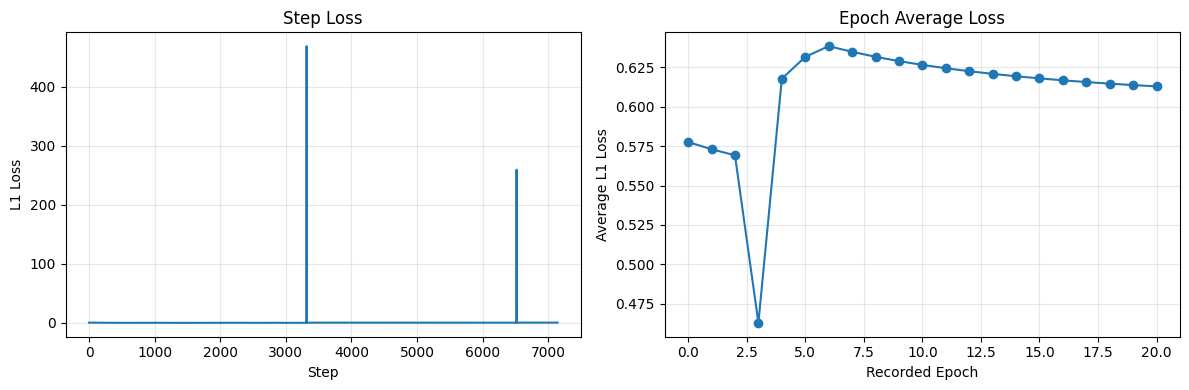

In [55]:
def plot_phase2_loss(result=None):
    if result is None:
        result = globals().get("phase2_result")

    if result is None:
        if not Path(CHECKPOINT_PATH).exists():
            print("No training result or checkpoint loss history found yet.")
            return None
        checkpoint = torch_load(CHECKPOINT_PATH, device)
        result = checkpoint.get("loss_history", {})

    step_losses = result.get("step_losses", [])
    epoch_losses = result.get("epoch_losses", [])
    if not step_losses and not epoch_losses:
        print("No loss values recorded yet. Run phase 2 training first.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if step_losses:
        axes[0].plot(step_losses)
        axes[0].set_title("Step Loss")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("L1 Loss")
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].axis("off")

    if epoch_losses:
        axes[1].plot(epoch_losses, marker="o")
        axes[1].set_title("Epoch Average Loss")
        axes[1].set_xlabel("Recorded Epoch")
        axes[1].set_ylabel("Average L1 Loss")
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return None


plot_phase2_loss(globals().get("phase2_result"));


## Inference

In [56]:
def spectrum_to_image(freq_2ch):
    complex_spectrum = torch.complex(freq_2ch[:, 0, :, :], freq_2ch[:, 1, :, :])
    spatial = torch.fft.ifft2(
        torch.fft.ifftshift(complex_spectrum, dim=(-2, -1)),
        dim=(-2, -1),
    ).real
    image = spatial[0].detach().cpu().numpy()
    return np.clip(image, 0.0, 1.0)


def load_phase2_for_inference():
    checkpoint_path = Path(CHECKPOINT_PATH)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}. Run phase 2 training first.")

    context_encoder, target_encoder, predictor, decoder, optimizer_phase_2 = build_phase2_models()
    checkpoint = torch_load(checkpoint_path, device)

    saved_arch = checkpoint.get("architecture_version")
    if saved_arch is not None and saved_arch != ARCHITECTURE_VERSION:
        raise RuntimeError(
            f"{CHECKPOINT_PATH} was saved for {saved_arch}, but this notebook uses {ARCHITECTURE_VERSION}."
        )

    context_encoder.load_state_dict(checkpoint["context_encoder"])
    predictor.load_state_dict(checkpoint["predictor"])
    decoder.load_state_dict(checkpoint["decoder"])

    context_encoder.eval()
    predictor.eval()
    decoder.eval()
    return context_encoder, predictor, decoder


def image_to_frequency_batch(image_path):
    image_path = Path(image_path)
    bgr_image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr_image is None:
        raise FileNotFoundError(f"Image not found or unreadable: {image_path}")

    height, width = TARGET_HW
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    rgb_image = cv2.resize(rgb_image, (width, height), interpolation=cv2.INTER_AREA)
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

    extractor = Extraction(target_hw=TARGET_HW, radius_ratio=RADIUS_RATIO, device=device)
    cpu_tensor = torch.from_numpy(gray_image).unsqueeze(0)
    if extractor.device.type == "cuda":
        cpu_tensor = cpu_tensor.pin_memory()

    with torch.no_grad():
        spatial_tensor = cpu_tensor.to(
            device=device,
            dtype=torch.float32,
            non_blocking=extractor.device.type == "cuda",
        ).unsqueeze(1).mul_(1.0 / 255.0)

        fft_complex = torch.fft.fftshift(torch.fft.fft2(spatial_tensor), dim=(-2, -1))
        low_pass_mask = extractor._create_circular_mask(height, width)
        low_freq_complex = fft_complex * low_pass_mask
        high_freq_complex = fft_complex - low_freq_complex
        low_frequency = torch.cat([low_freq_complex.real, low_freq_complex.imag], dim=1)
        high_frequency = torch.cat([high_freq_complex.real, high_freq_complex.imag], dim=1)

    return low_frequency, high_frequency, rgb_image.astype(np.float32) / 255.0


def load_inference_sample():
    if IMAGE_PATH:
        low_freq, high_freq_target, input_rgb = image_to_frequency_batch(IMAGE_PATH)
        return low_freq, high_freq_target, input_rgb, Path(IMAGE_PATH)

    video_path = Path(VIDEO_PATH)
    if not video_path.exists():
        raise FileNotFoundError(f"Training video not found: {video_path}")

    extractor = Extraction(target_hw=TARGET_HW, radius_ratio=RADIUS_RATIO, device=device)
    low_freq, high_freq_target = next(extractor.stream_video_batches(video_path, batch_size=1))
    return low_freq, high_freq_target, None, video_path


def run_inference(save_path=INFERENCE_OUTPUT_PATH):
    context_encoder, predictor, decoder = load_phase2_for_inference()
    low_freq, high_freq_target, input_rgb, source_path = load_inference_sample()

    with torch.no_grad():
        s_x = context_encoder(low_freq)
        pred_y = predictor(s_x)
        reconstructed_high = decoder(s_x, pred_y)

    original_image = spectrum_to_image(low_freq + high_freq_target)
    low_only_image = spectrum_to_image(low_freq)
    reconstructed_image = spectrum_to_image(low_freq + reconstructed_high)
    error_image = np.abs(original_image - reconstructed_image)

    output_u8 = np.clip(reconstructed_image * 255.0, 0, 255).astype(np.uint8)
    cv2.imwrite(str(save_path), output_u8)
    print(f"Saved inference result: {save_path}")

    return {
        "source_path": source_path,
        "input_rgb": input_rgb,
        "original": original_image,
        "low_only": low_only_image,
        "reconstructed": reconstructed_image,
        "error": error_image,
        "save_path": Path(save_path),
    }


inference_result = run_inference()
inference_result["save_path"]


Saved inference result: final_reconstruction.jpg


WindowsPath('final_reconstruction.jpg')

## Result

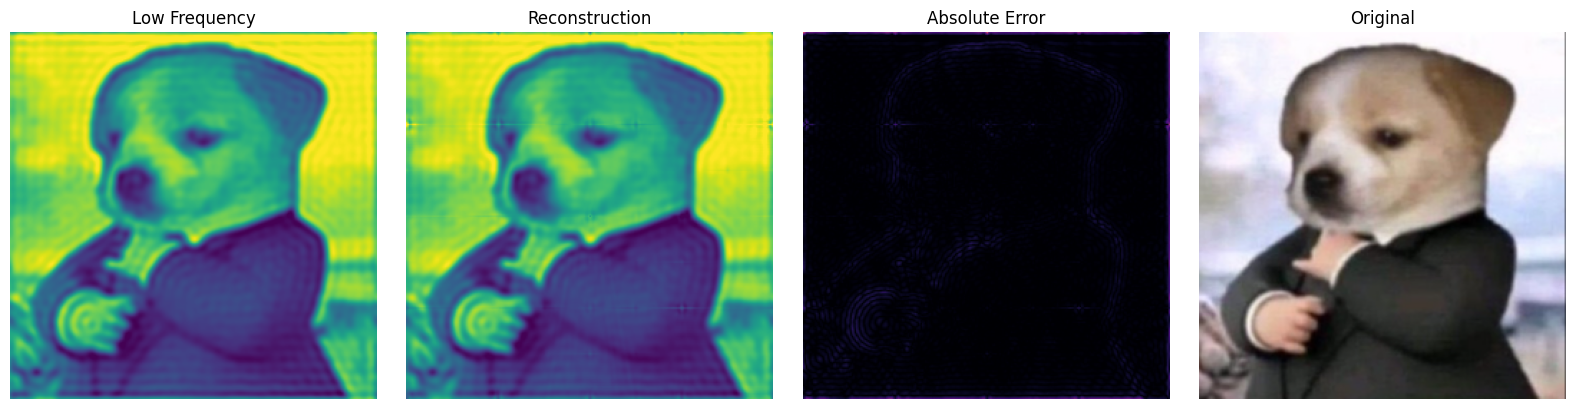

In [57]:
def show_inference_result(result=None):
    if result is None:
        result = globals().get("inference_result")
    if result is None:
        print("No inference result found. Run the Inference cell first.")
        return None

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    original_display = result["input_rgb"] if result.get("input_rgb") is not None else result["original"]
    original_cmap = None if result.get("input_rgb") is not None else "gray"
    images = [
        ("Low Frequency", result["low_only"], "viridis"),
        ("Reconstruction", result["reconstructed"], "viridis"),
        ("Absolute Error", result["error"], "magma"),
        ("Original", original_display, original_cmap),
    ]

    for ax, (title, image, cmap) in zip(axes, images):
        if image.ndim == 2:
            ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return None


show_inference_result(globals().get("inference_result"));